# Lectura de tonos en un telefono de linea
123\
456\
789\
*0#

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from scipy.signal.windows import flattop, hamming

#### Busca picos y piso de ruido

In [128]:
# Busca los 5 mayores valores dentro de todas las magnitudes y retorna la frecuencia y magnitud de dichos picos
def busca_picos(magnitudes, frecuencias): #magnitud dbV
    # Se encuentran los picos y se los ordena en bajo y alto
    picos, _ = find_peaks(magnitudes, distance=10)
    picos = picos[np.argsort(magnitudes[picos])[::-1]]

    tonos = picos[:2] #Los 2 mayores (tonos)
    tonos_sorted = sorted(tonos, key=lambda i: frecuencias[i]) # Ordeno por frecuencia

    armonicos = picos[2:4] #Los terceros y cuartos mayores (armonicos)
    armonicos_sorted = sorted(armonicos, key=lambda i: frecuencias[i])

    espuria = picos[4] #Quinto mayor (espuria)

    picos_interes = tonos_sorted + armonicos_sorted + [espuria]

    return {
        "picos": picos_interes, #indices en el arr magnitud y frecuencia
        # Valores explicitos de la frecuencia y magnitud de cada pico
        "tono_bajo": {"frecuencia": frecuencias[tonos_sorted[0]], "magnitud": magnitudes[tonos_sorted[0]]},
        "tono_alto": {"frecuencia": frecuencias[tonos_sorted[1]], "magnitud": magnitudes[tonos_sorted[1]]},
        "armonico_bajo": {"frecuencia": frecuencias[armonicos_sorted[0]], "magnitud": magnitudes[armonicos_sorted[0]]},
        "armonico_alto": {"frecuencia": frecuencias[armonicos_sorted[1]], "magnitud": magnitudes[armonicos_sorted[1]]},
        "espuria": {"frecuencia": frecuencias[espuria], "magnitud": magnitudes[espuria]}
    }

# Calcula el piso de ruido como la mediana de magnitudes ignorando picos de las señal
def piso_ruido(magnitud_db, picos):
    picos = picos[:4] # Remuevo la espuria para que no se la ignore en el calculo
    # Piso de ruido (mediana de la FFT excluyendo los dos tonos y valores cercanos)
    mascara = np.ones(len(magnitud_db), dtype=bool)
    # Para el calculo de piso de ruido ignoro valores cercanos a los picos
    for indice in picos:
        ini = max(0, indice - 5)
        fin = min(len(magnitud_db), indice + 6)
        mascara[ini:fin] = False

    piso_ruido_db = np.median(magnitud_db[mascara])
    return piso_ruido_db

### Ventaneo

In [129]:
def ventaneo(signal, ventana='flattop'):
    if ventana == 'hanning':
        ventana = hamming(len(signal), sym=False)
        signal *= ventana
    elif ventana == 'flattop':
        ventana = flattop(len(signal), sym=False)
        ventana /= np.mean(ventana) #Coherent Gain
        signal *= ventana
    return signal

#### procesar_mediciones
Abre los archivos en bloques de a 5, correspondiente a las 5 mediciones de cada tecla.

Retorna
- "tiempo": arr de la primera lectura
- "voltaje": arr de la primera lectura
- "frecuencia": arr de 0 a 5000hz
- "magnitud": dB promedio
- "magnitud_dbv": arr en dBV
- "magnitud_dbm": arr en dBm con una impedancia de entrada de 600ohms
- "picos": Indice, frecuencia y amplitud de los 2 tonos, los 2 armonicos y la primera espuria
- "piso_ruido_db": piso de ruido, si es en dBm o dBV depende del parametro utilizado
- "N": cantidad de medidas

In [130]:
def procesar_mediciones(archivos, dt=1.00000e-04):
    # dt es igual para todas las medidas
    N = None
    #arr para guardar las potencias de las fft de cada archivo
    # Se separan en amplitud y frecuencia para aplicar ventanas
    # distintas segun lo que se quiere analizar
    potencias_amp = []
    potencias_freq = []

    tiempo = None
    voltaje = None

    for i, archivo in enumerate(archivos):

        df = pd.read_csv(archivo,
            skiprows=16, # Saltea informacion sobre el muestreo
            names=['Tiempo', 'Voltaje'],index_col=False)

        if N is None:
            N = len(df)

        # Guardo la primera señal para graficar en tiempo
        if i == 0:
            tiempo = df["Tiempo"].to_numpy()
            voltaje = df["Voltaje"].to_numpy()

        signal = df["Voltaje"].to_numpy()

        # FFT
        signal = df["Voltaje"].to_numpy()
        
        signal = signal - np.mean(signal) # Elimino DC

        # Ventaneo la señal
        signal_flattop = ventaneo(signal, 'flattop') #flattop para amplitudes
        signal_hamming = ventaneo(signal, 'hamming') #hamming para frecuencias

        fft_amp = fft(signal_flattop)
        fft_freq = fft(signal_hamming)

        mitad = N // 2

        magnitud_amp = (2.0 / N) * np.abs(fft_amp[:mitad])
        magnitud_freq = (2.0 / N) * np.abs(fft_freq[:mitad])

        # Promediar únicamente la FFT de amplitud
        potencias_amp.append(magnitud_amp**2)
        potencias_freq.append(magnitud_freq**2)
    
# Frecuencias
    frecuencias = fftfreq(N, dt)[:mitad]

    # Promedio RMS
    potencia_amp = np.mean(potencias_amp, axis=0)
    potencia_freq = np.mean(potencias_freq, axis=0)

    magnitud_promedio = np.sqrt(potencia_amp)
    magnitud_freq = np.sqrt(potencia_freq)

# MAGNITUDES
    # dBV
    magnitud_rms = magnitud_promedio / np.sqrt(2)
    magnitud_dbv = 20 * np.log10(np.clip(magnitud_rms, 1e-5, None))
    
    #dBm
    R = 600 # Impedancia de entrada de 600ohms
    vref = np.sqrt(1e-3*R)
    magnitud_dbm = 20*np.log10(magnitud_rms/vref)
    #magnitud_dbm = 20*np.log10(np.clip(magnitud_rms,1e-12,None))-10*np.log10(R)+30

# Picos y piso ruido (dbm)
    magnitud_freq_db = 20*np.log10(np.clip(magnitud_freq/np.sqrt(2), 1e-5, None))  #FFT de frecuencia de la última medición
    picos = busca_picos(magnitud_freq_db, frecuencias) # Buscar picos con Hamming
    piso_ruido_db = piso_ruido(magnitud_dbm, picos["picos"]) # Piso de ruido con Flat Top

    return {
        "tiempo": tiempo,
        "voltaje": voltaje,
        "frecuencia": frecuencias,
        "magnitud": magnitud_promedio,
        "magnitud_dbv": magnitud_dbv,
        "magnitud_dbm": magnitud_dbm,
        "picos": picos,
        "piso_ruido_db": piso_ruido_db,
        "N": N
    }

Grafica la FFT con las coordenadas de los 2 picos maximos y el piso de ruido

In [131]:
def graficar_fft(frecuencias, magnitud, picos, piso_ruido, titulo, ax):

    ax.plot(frecuencias,magnitud,color="red",linewidth=1.2)

    ax.axhline( # Linea del piso de ruino
        piso_ruido,
        color="blue",
        linestyle="--",
        linewidth=1
    )

    ax.text( # Leyenda del piso de ruido
        0.98,
        0.03,
        f"Ruido: {piso_ruido:.1f} dB",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    for indice in picos:
        freq = frecuencias[indice]
        amp = magnitud[indice]

        ax.scatter(freq, amp, s=25, color="blue")

        ax.annotate(
            f"{freq:.0f} Hz\n{amp:.1f} dB",
            (freq, amp),
            textcoords="offset points",
            xytext=(6,-6), # Distancia del texto al punto
            fontsize=12,
            bbox=dict(
                facecolor="gray", # Color de fondo (caja)
                alpha=0.3, # Transparencia
                edgecolor="none"
            )
        )

    ax.set_title(f"Tecla {titulo}", fontsize=12)
    ax.set_xlim(0, 2000)
    ax.grid(True, alpha=0.4)

## Codigo principal
Esta seccion declara las teclas y tonos nominales, y llama a las funciones de fft y graficos en ciclo para leer todos los archivos, procesarlos, promediarlos y graficarlos. Guarda los resultados para graficar o expresarlos en una tabla.

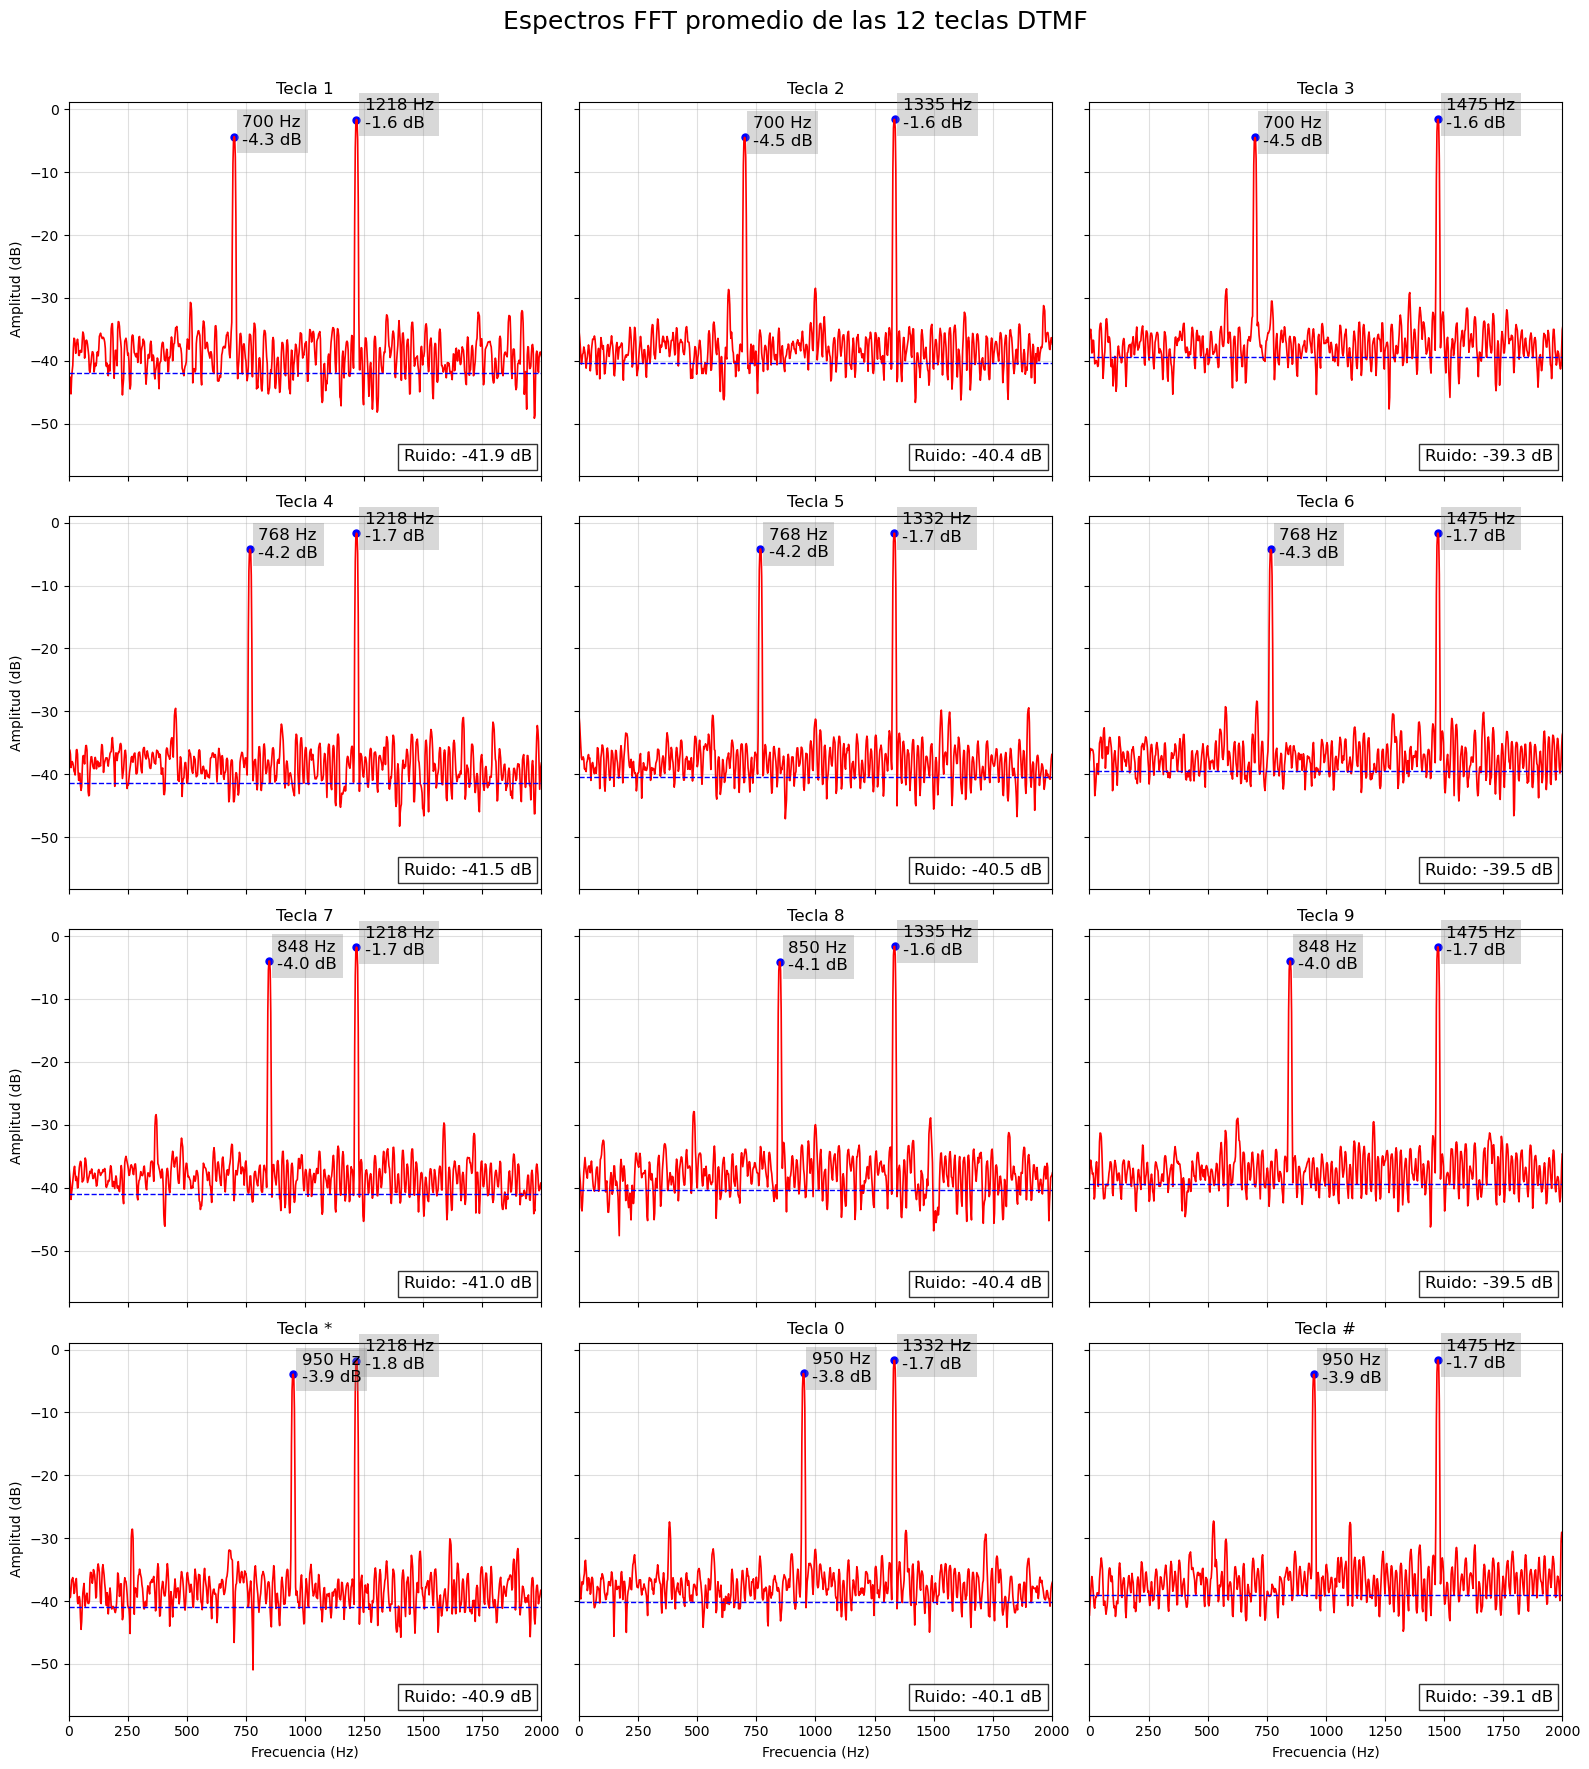

In [132]:
tono_columna = [1209, 1336, 1477]
tono_fila = [697, 770, 852, 941]

teclas = [
    ['1', '2', '3'],
    ['4', '5', '6'],
    ['7', '8', '9'],
    ['*', '0', '#']
]

tabla_tonos_hz = []
resumen_db = []

fig, axs = plt.subplots(
    4,
    3,
    figsize=(16, 18),
    sharex=True,
    sharey=True
)

contador_archivo = 0

for fila, fila_teclas in enumerate(teclas):

    for columna, tecla in enumerate(fila_teclas):

        archivos = [ # Carga los archivos de a tandas de 5 mediciones
            f"medidas/DS{contador_archivo+i:04d}.CSV"
            for i in range(5)
        ]

        contador_archivo += 5

        res = procesar_mediciones(archivos)
        
        tonos_detectados = res["picos"]["picos"][:2] # Paso solo los picos de los tonos
        #par de tonos que se esperan por la fila y columna de la tecla
        tonos_esperados = np.sort([tono_fila[fila],tono_columna[columna]])


        tabla_tonos_hz.append([
            tecla,
            tonos_esperados[0],
            res["picos"]["tono_bajo"]["frecuencia"],
            tonos_esperados[1],
            res["picos"]["tono_alto"]["frecuencia"],
        ])
        resumen_db.append([
            tecla,
            res["picos"]["picos"],
            res["magnitud_dbm"],
            res["piso_ruido_db"]
        ])

        #resumen_db.append([
        #    tecla,
        #    res["picos"], #aca van los tonos, armonicos y espuria (frecuencia y magnitud)
        #    res["piso_ruido_db"],
        #])

#############
# Para usar dBV o dBm tambien cambiarlo en picos y piso de ruido
# en procesar_mediciones()
#############
        graficar_fft(res["frecuencia"], 
                res["magnitud_dbm"], 
                #res["magnitud_dbv"], 
                tonos_detectados, res["piso_ruido_db"], 
                tecla, axs[fila, columna])

# Etiquetas solo en los bordes
for ax in axs[-1, :]:
    ax.set_xlabel("Frecuencia (Hz)")

for ax in axs[:, 0]:
    ax.set_ylabel("Amplitud (dB)")

fig.suptitle(
    "Espectros FFT promedio de las 12 teclas DTMF",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Analisis de todo el espectro

Para mejorar la visualizacion se corta el eje a los 2000hz en los graficos anteriores, aca se aprecia todo el espectro y se ven los 2 picos armonicos en altas frecuencias.

<Figure size 640x480 with 0 Axes>

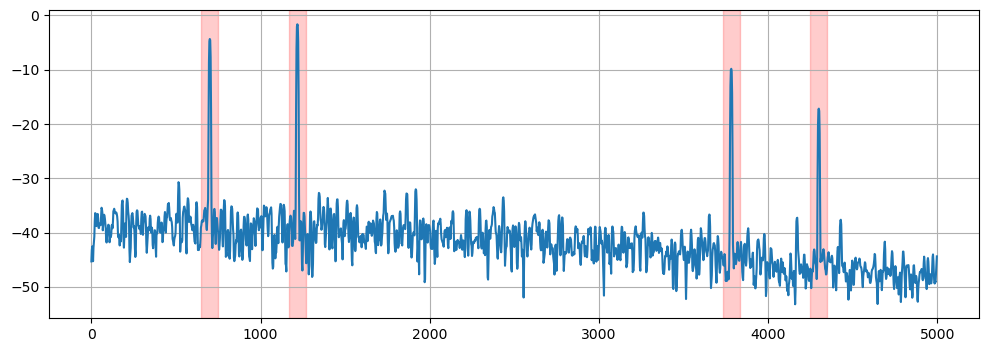

In [133]:
archivos = [
    f"medidas/DS{0+i:04d}.CSV"
    for i in range(5)
]

resultado = procesar_mediciones(archivos)

fig.suptitle(
    "Espectros FFT promedio de las 12 teclas DTMF",
    fontsize=18
)
top_4 = resultado["picos"]["picos"][:4]

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

plt.figure(figsize=(12,4))
plt.plot(resultado["frecuencia"], resultado["magnitud_dbm"])

for indice in top_4:
    plt.axvspan(
        resultado["frecuencia"][max(0, indice-20)],
        resultado["frecuencia"][min(len(resultado["frecuencia"])-1, indice+20)],
        color="red",
        alpha=0.2
    )
plt.grid(True)

### Graficos en tiempo

Con el parametro division se deja como esta o reduce el eje en tiempo. Jugando con este parametro de division se puede visualizar el efecto alias

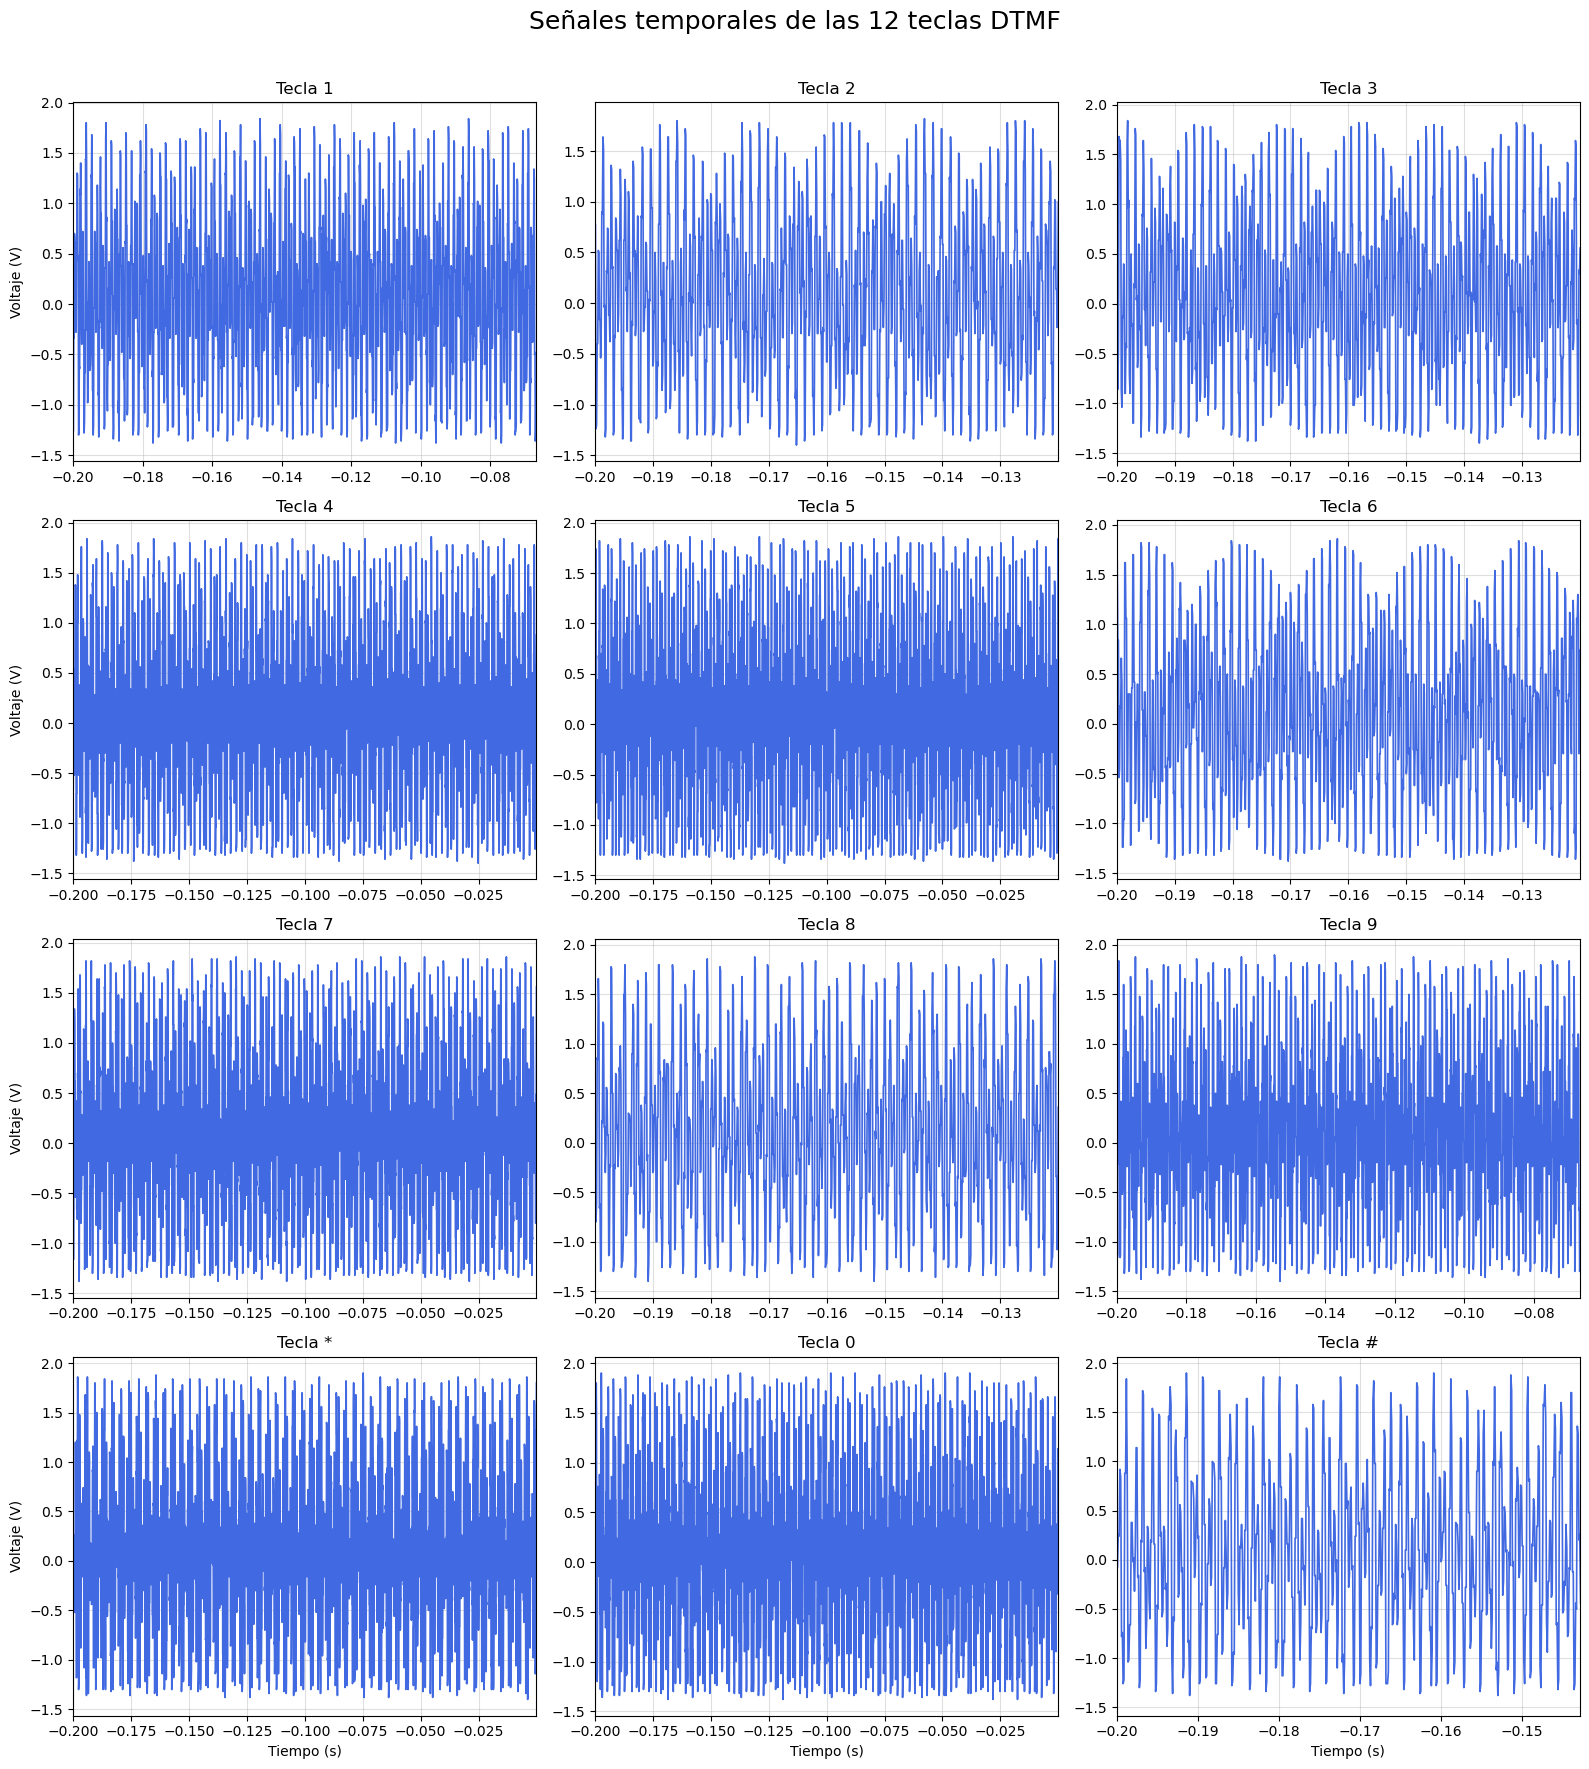

In [134]:
def graficar_senal(resultado, titulo, ax, division):

    tiempo = resultado["tiempo"]
    voltaje = resultado["voltaje"]

    ax.plot(
        tiempo,
        voltaje,
        color="royalblue",
        linewidth=1.2
    )

    # Mostrar sólo una pequeña porción para apreciar la forma de onda
    ax.set_xlim(
        tiempo[0],
        tiempo[0] + (tiempo[-1] - tiempo[0]) / division
    )

    ax.set_title(f"Tecla {titulo}", fontsize=12)
    ax.grid(True, alpha=0.4)

fig, axs = plt.subplots(
    4,
    3,
    figsize=(16, 18),
)

contador_archivo = 0

for fila, fila_teclas in enumerate(teclas):

    for columna, tecla in enumerate(fila_teclas):

        archivos = [
            f"medidas/DS{contador_archivo+i:04d}.CSV"
            for i in range(5)
        ]

        contador_archivo += 5
        division = 2
        if tecla == '1' or tecla == '9':
            division = 3
        elif tecla == '#':
            division = 7
        elif tecla == '2' or tecla == '3' or tecla == '6' or tecla == '8':
            division = 5

        #print(f"Tecla {tecla}: división = {division}")
        resultado = procesar_mediciones(archivos)

        graficar_senal(
            resultado,
            tecla,
            axs[fila, columna],
            division
        )

for ax in axs[-1, :]:
    ax.set_xlabel("Tiempo (s)")

for ax in axs[:, 0]:
    ax.set_ylabel("Voltaje (V)")

fig.suptitle(
    "Señales temporales de las 12 teclas DTMF",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Tablas


### Tabla de frecuencias

In [135]:
tabla = []

for tecla, esp1, det1, esp2, det2 in tabla_tonos_hz:

    err1 = 100 * abs(det1 - esp1) / esp1
    err2 = 100 * abs(det2 - esp2) / esp2

    tabla.append([
        tecla,
        esp1,
        round(det1, 1),
        round(err1, 2),
        esp2,
        round(det2, 1),
        round(err2, 2)
    ])

df_resumen = pd.DataFrame(
    tabla,
    columns=[
        "Tecla",
        "Esp. Bajo",
        "Det. Bajo",
        "Error (%)",
        "Esp. Alto",
        "Det. Alto",
        "Error (%)"
    ]
)

print(df_resumen)

   Tecla  Esp. Bajo  Det. Bajo  Error (%)  Esp. Alto  Det. Alto  Error (%)
0      1        697      700.0       0.43       1209     1217.5       0.70
1      2        697      700.0       0.43       1336     1335.0       0.07
2      3        697      700.0       0.43       1477     1475.0       0.14
3      4        770      767.5       0.32       1209     1217.5       0.70
4      5        770      767.5       0.32       1336     1332.5       0.26
5      6        770      767.5       0.32       1477     1475.0       0.14
6      7        852      847.5       0.53       1209     1217.5       0.70
7      8        852      850.0       0.23       1336     1335.0       0.07
8      9        852      847.5       0.53       1477     1475.0       0.14
9      *        941      950.0       0.96       1209     1217.5       0.70
10     0        941      950.0       0.96       1336     1332.5       0.26
11     #        941      950.0       0.96       1477     1475.0       0.14


### Tabla de dB

In [136]:
tabla = []

for tecla, picos, magnitud ,piso_ruido in resumen_db:

    tono_bajo_db = magnitud[picos[0]]
    tono_alto_db = magnitud[picos[1]]
    espuria_db = magnitud[picos[4]]

    tabla.append([
        tecla,
        round(tono_bajo_db, 2),
        round(tono_alto_db, 2),
        round(piso_ruido, 2),
        round(tono_alto_db - tono_bajo_db, 2),
        round(espuria_db - tono_bajo_db, 2)
        # Falta obtener la espuria posta, que seria el quinto mayor pico de la FFT 
        # El primero y segundo mayor: los dos tonos
        # tercer y cuarto mayor: los armonicos (espurias "falsas")
        # Quinto mayor : la espuria posta que nos interesa tener para el analisis
    ])

df_db = pd.DataFrame(
    tabla,
    columns=[
        "Tecla",
        "Tono bajo (dB)",
        "Tono alto (dB)",
        "Piso de ruido (dB)",
        "Preenfasis (dB)",
        "Espuria (dB)"
    ]
)

print(df_db)

   Tecla  Tono bajo (dB)  Tono alto (dB)  Piso de ruido (dB)  Preenfasis (dB)  \
0      1           -4.33           -1.63              -41.91             2.71   
1      2           -4.46           -1.61              -40.40             2.85   
2      3           -4.48           -1.59              -39.32             2.89   
3      4           -4.21           -1.65              -41.45             2.56   
4      5           -4.17           -1.67              -40.45             2.50   
5      6           -4.26           -1.66              -39.50             2.60   
6      7           -3.96           -1.75              -41.01             2.22   
7      8           -4.08           -1.62              -40.42             2.46   
8      9           -3.97           -1.71              -39.45             2.26   
9      *           -3.92           -1.76              -40.95             2.16   
10     0           -3.81           -1.72              -40.07             2.09   
11     #           -3.94    

### Tabla armonicos

Analisis de los dos tonos que aparecen en altas frecuencias (>3000hz)

In [137]:
tabla = []

for tecla, picos, magnitud, piso_ruido in resumen_db:

    tono_bajo_db = picos["tono_bajo"]["frecuencia"]
    tono_alto_db = picos["tono_alto"]["frecuencia"]
    espuria_db = picos["armonico_bajo"]["frecuencia"]

    tabla.append([
        tecla,
        round(picos["tono_bajo"]["frecuencia"], 2),
        round(picos["tono_alto"]["frecuencia"], 2),
        round(picos["armonico_bajo"]["frecuencia"], 2),
        round(picos["armonico_alto"]["frecuencia"], 2)
    ])

df_db = pd.DataFrame(
    tabla,
    columns=[
        "Tecla",
        "Tono bajo (hz)",
        "Tono alto (hz)",
        "Armonico bajo (hz)",
        "Armonico alto (hz)"
    ]
)

print(df_db)

TypeError: list indices must be integers or slices, not str

## Test
Verifico calculo de magnitud dBV

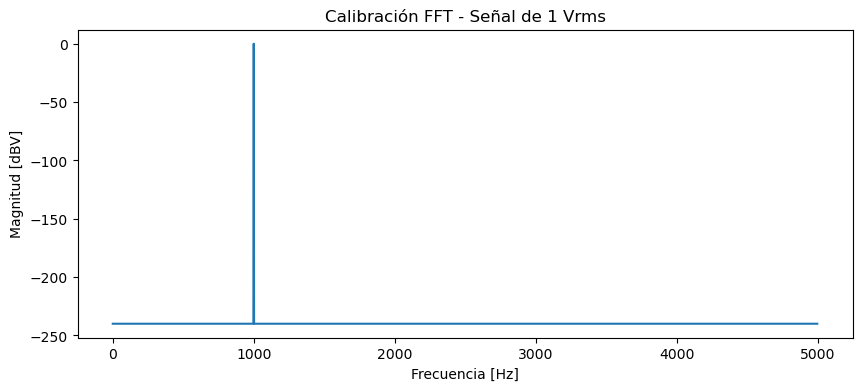

In [ ]:
def procesar_medicion_test(dt=1e-4):

    # Parámetros
    N = 4000
    Fs = 1/dt

    # Señal de prueba
    Vrms = 1                      # 1 Vrms
    Vp = Vrms * np.sqrt(2)        # amplitud pico

    f = 1000                      # Hz (menor que Fs/2)

    tiempo = np.arange(N) * dt
    voltaje = Vp * np.sin(2*np.pi*f*tiempo)

    # FFT
    fft_valores = fft(voltaje)
    mitad = N // 2

    magnitud = (2.0 / N) * np.abs(fft_valores[:mitad])

    # Corrección DC y Nyquist
    magnitud[0] /= 2
    if N % 2 == 0:
        magnitud[-1] /= 2

    # Frecuencias
    frecuencias = fftfreq(N, dt)[:mitad]

    # Conversión a RMS
    magnitud_rms = magnitud / np.sqrt(2)

    # dBV
    magnitud_dbv = 20*np.log10(np.clip(magnitud_rms, 1e-12, None))

    # dBm (600 ohm)
    R = 600
    magnitud_dbm = (
        20*np.log10(np.clip(magnitud_rms, 1e-12, None))
        - 10*np.log10(R)
        + 30
    )

    # Buscar picos (para la prueba usar dBV)
    #picos = busca_picos(magnitud_dbv, frecuencias)
    #piso_ruido_db = piso_ruido(magnitud_dbv, picos["picos"])

    return {
        "tiempo": tiempo,
        "voltaje": voltaje,
        "frecuencia": frecuencias,
        "magnitud": magnitud,
        "magnitud_dbv": magnitud_dbv,
        "magnitud_dbm": magnitud_dbm,
        "N": N
    }


# ===========================
# Ejecutar prueba de calibración
# ===========================

res = procesar_medicion_test()
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(res["frecuencia"], res["magnitud_dbv"])
#ax.plot(frecuencia_pico, nivel_pico, "ro")

ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Magnitud [dBV]")
ax.set_title("Calibración FFT - Señal de 1 Vrms")

plt.show()